In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Cargamos el dataset de precios de casas

In [25]:
data = pd.read_csv("precio_casas.csv")
data

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades
...,...,...,...,...,...,...,...,...,...,...,...,...
7774,2491300000,70000,3102491,LasCondes,CalleSanJosédeLaSierra,5,5.0,600.0,1800.0,5.0,4708915,Propiedades Viña Limitada ®
7775,242012000,6800,301385,Peñalolén,PasajeMarNegro,4,2.0,124.0,200.0,1.0,6641660,NaN
7776,3736950000,105000,4653736,LasCondes,CaminoLasFlores/CaminoPiedraRoja,5,7.0,460.0,4925.0,8.0,6032811,Tsi Property
7777,569440000,16000,709141,LaPintana,LosCipreses/LosDuraznos,4,2.0,311.0,2011.0,1.0,5314376,Tsi Property


In [26]:
data.columns

Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='str')

In [27]:
data.describe()

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,7.779000e+03,7779.000000,7.779000e+03,7779.000000,7714.000000,7533.000000,7571.000000,5489.000000,7.779000e+03
mean,3.642481e+08,10234.571153,4.536091e+05,3.994087,2.653746,229.923669,807.919826,2.980506,9.910828e+06
std,3.868810e+08,10870.491584,4.817945e+05,1.622821,1.465103,1676.898812,9050.893115,17.749384,2.046317e+06
min,2.085000e+03,0.000000,3.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.213620e+06
25%,1.200000e+08,3372.000000,1.494400e+05,3.000000,2.000000,85.000000,129.500000,1.000000,8.563078e+06
50%,2.050000e+08,5760.000000,2.552930e+05,4.000000,2.000000,128.000000,210.000000,2.000000,1.054807e+07
75%,4.911420e+08,13800.000000,6.116340e+05,5.000000,3.000000,200.000000,443.000000,3.000000,1.152463e+07
max,5.516450e+09,155000.000000,6.869801e+06,27.000000,29.000000,120000.000000,678000.000000,1269.000000,1.234149e+07


Eliminamos todas aquellas columnas que no resultan utiles para el modelo, nos quedamos con la columna "Comuna", porque podria ser considerado el atributo mas importante de una casa, ya que la ubicacion puede ser trascendental en el precio de una casa

In [28]:
data = data.drop(columns=["Ubicacion", "Realtor", "id", "Price_USD", "Price_CLP"])
data.columns

Index(['Price_UF', 'Comuna', 'Dorms', 'Baths', 'Built Area', 'Total Area',
       'Parking'],
      dtype='str')

Vamos a ver como se distribuyen los datos antes de limpiarlos, aqui se pueden ver los valores atipicos claramente en el histograma y en los graficos de caja

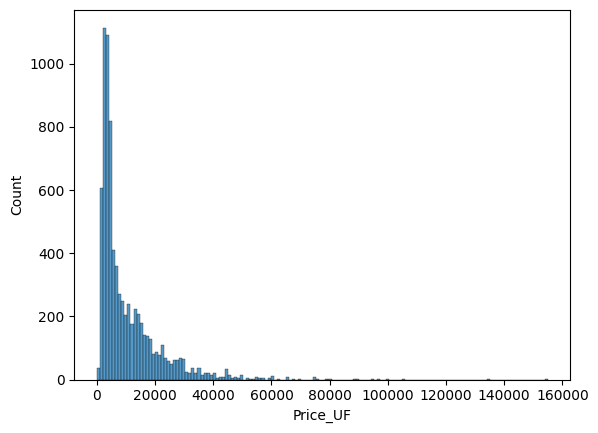

In [29]:
sns.histplot(data=data, x="Price_UF")
plt.show()

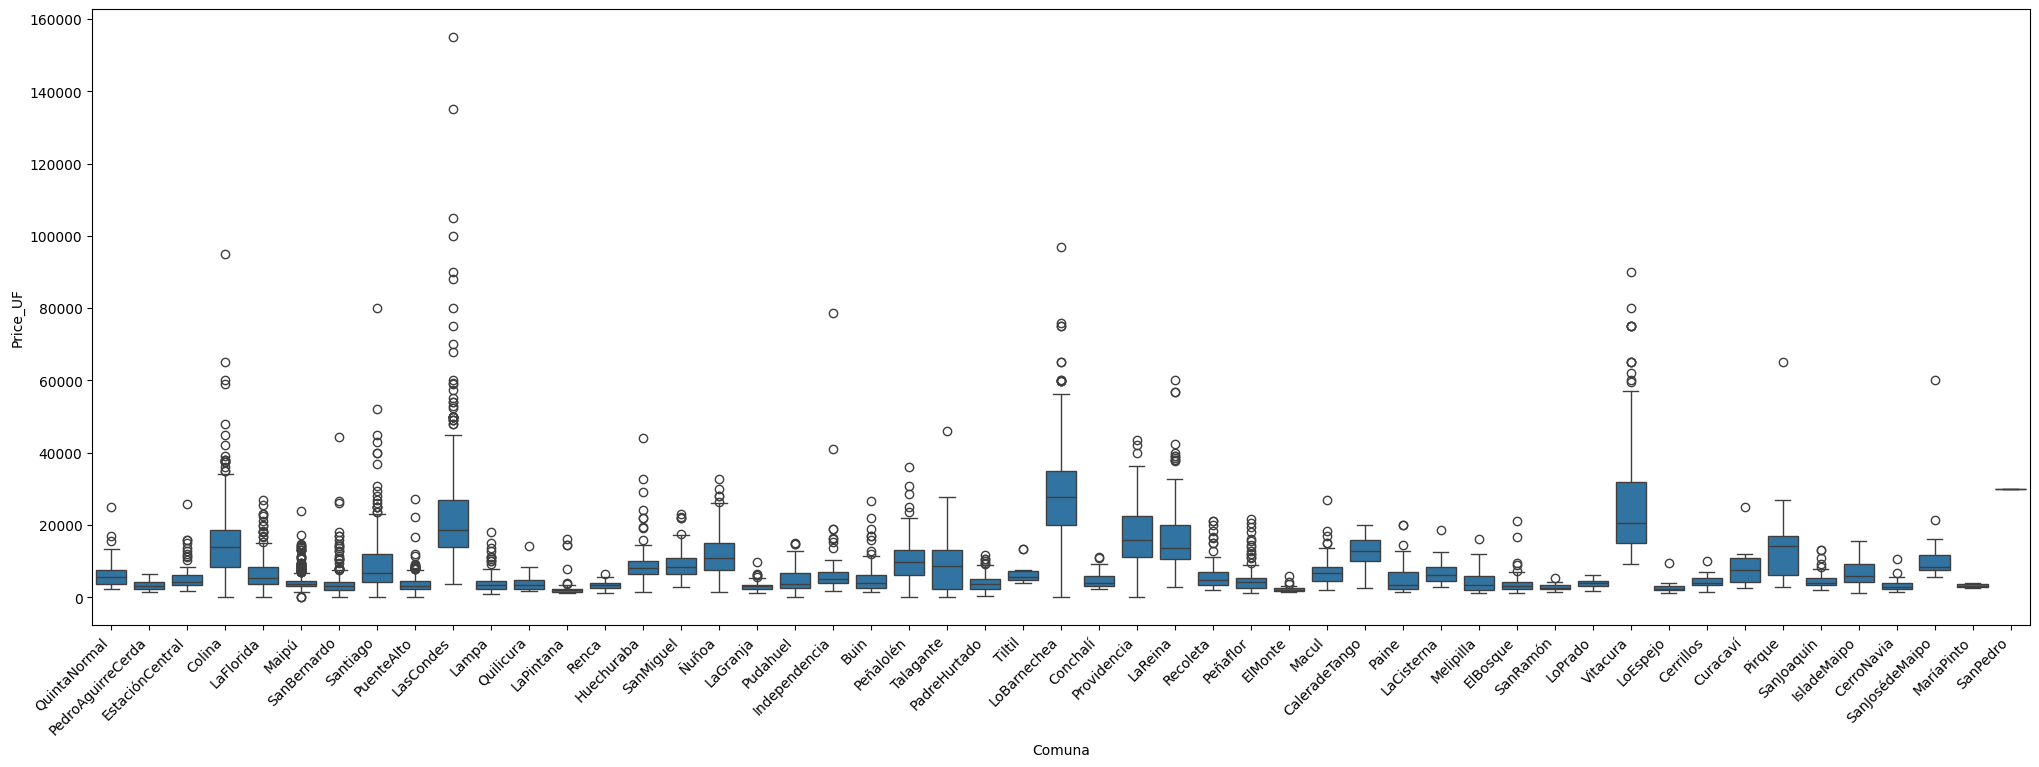

In [39]:
plt.figure(figsize=(25, 8))
sns.boxplot(data=data, x="Comuna", y="Price_UF")
plt.xticks(rotation=45, ha="right")
plt.show()

Necesitamos eliminar valores atipicos que pueden confundir a nuestro modelo, se puede ver en los boxplots que hay muchos valores atipicos que pueden ensuciar el aprendizaje del ML, eliminar estos valores extremos es importante porque queremos que nuestro modelo sea bueno estimando casas "normales" o "populares", sin que se vea sesgado por grandes propiedades o viviendas con caracteristicas muy fuera de lo comun, al quedarnos con los datos mas representativos del mercado general, el modelo puede aprender mejor los patrones tipicos y hacer predicciones mas precisas para la mayoria de los casos, enfocandonos en lo mas popular sin irnos a lo mas lejano. Para esto utilizare el metodo iqr visto en el notebook 08.house_pricing.ipynb del repositorio del curso

In [ ]:
def iqr(data, column): 
    q3 = data[column].quantile(0.75) 
    q1 = data[column].quantile(0.25) 
    superior_limit = q3 + 1.5*(q3 - q1)
    inferior_limit = q1 - 1.5*(q3 - q1)
    return data[(data[column] < superior_limit) & (data[column] > inferior_limit)] 

Aplicamos el filtro iqr a todas las columnas numericas, incluyendo Price_UF, para sacar los valores atipicos, esto nos permite enfocarnos en las casas con precios mas tipicos del mercado y no en las propiedades extremadamente caras o baratas que podrian distorsionar nuestro modelo

In [40]:
data_limpia = data.copy()

for col in ["Dorms", "Baths", "Built Area", "Total Area", "Parking", "Price_UF"]:
    data_limpia = iqr(data_limpia, col)
data_limpia.shape

(3488, 7)

Eliminamos los valores nulos

In [33]:
for column in data_limpia.select_dtypes(include=[np.number]).columns:
    data_limpia = data_limpia[data_limpia[column].notna()]
    print(column, len(data_limpia[data_limpia[column].isna()]))

data_limpia

Price_UF 0
Dorms 0
Baths 0
Built Area 0
Total Area 0
Parking 0


,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking
1,2950,PedroAguirreCerda,2,1.0,112.0,145.0,1.0
2,3600,EstaciónCentral,3,1.0,59.0,243.0,2.0
3,2107,Colina,3,1.0,103.0,73.0,1.0
4,1489,Colina,2,1.0,57.0,67.0,1.0
6,2107,Colina,3,1.0,70.0,80.0,2.0
...,...,...,...,...,...,...,...
7767,0,Pudahuel,3,3.0,100.0,199.0,2.0
7768,5300,EstaciónCentral,4,2.0,114.0,220.0,3.0
7769,1264,LoEspejo,3,2.0,40.0,50.0,1.0
7772,2390,SanBernardo,5,1.0,120.0,76.0,1.0


Ahora vemos los mismos graficos pero con los datos limpios y notaremos la diferencia, los datos ahora estan mas concentrados y sin valores extremos

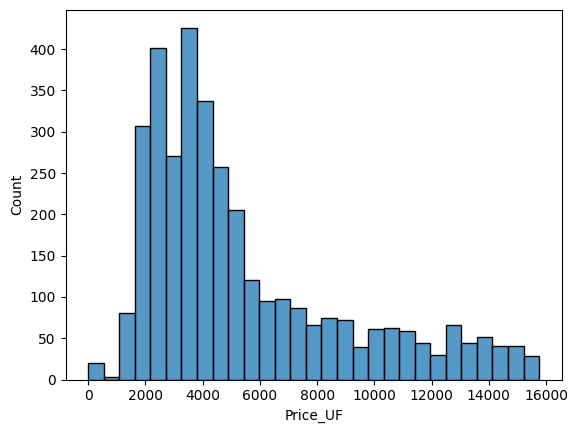

In [34]:
sns.histplot(data=data_limpia, x="Price_UF")
plt.show()

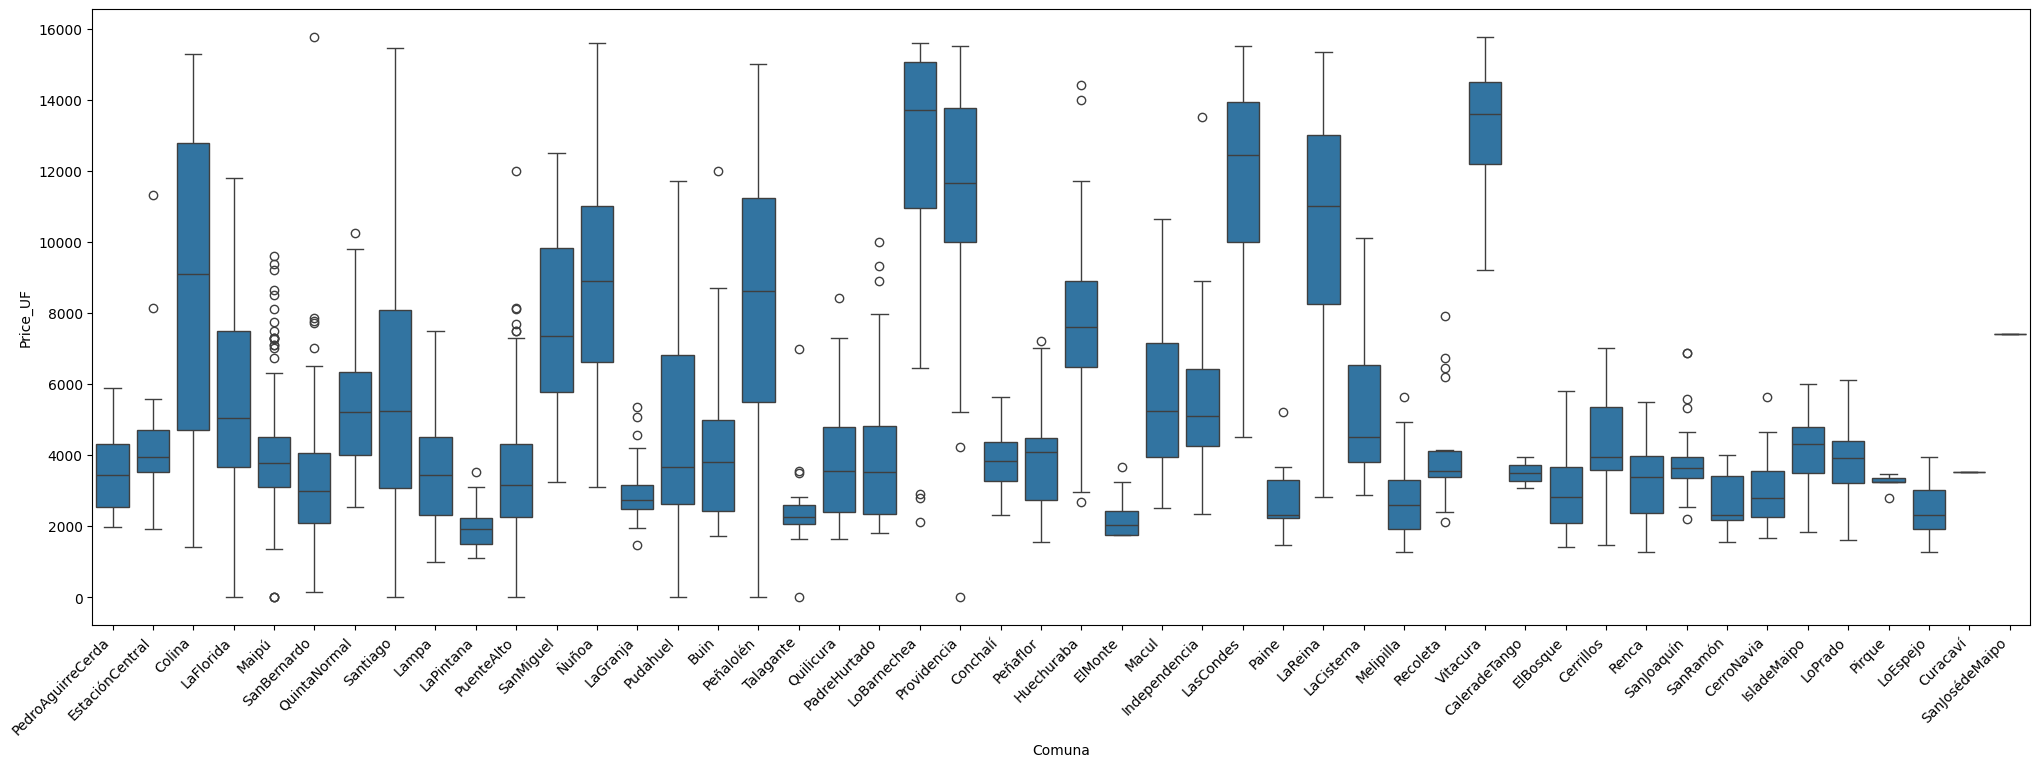

In [43]:
plt.figure(figsize=(25, 8))
sns.boxplot(data=data_limpia, x="Comuna", y="Price_UF")
plt.xticks(rotation=45, ha="right")
plt.show()

Como el modelo de regresion solo trabaja con numeros necesitamos convertir la columna "Comuna" (que es texto) a valores numericos, para eso usamos "get_dummies" que crea una columna binaria (0 o 1) por cada comuna. Asi el modelo puede aprender cuanto influye cada comuna en el precio final de la casa, que como vimos en el boxplot de arriba, es bastante significativo, como por ejemplo en comunas como Providencia, Conchali, Vitacura, etc

In [45]:
data_limpia = pd.get_dummies(data_limpia, columns=["Comuna"], drop_first=True, dtype=int)
data_limpia

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking,Comuna_CaleradeTango,Comuna_Cerrillos,Comuna_CerroNavia,Comuna_Colina,...,Comuna_Renca,Comuna_SanBernardo,Comuna_SanJoaquín,Comuna_SanJosédeMaipo,Comuna_SanMiguel,Comuna_SanRamón,Comuna_Santiago,Comuna_Talagante,Comuna_Vitacura,Comuna_Ñuñoa
1,2950,2,1.0,112.0,145.0,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3600,3,1.0,59.0,243.0,2.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2107,3,1.0,103.0,73.0,1.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1489,2,1.0,57.0,67.0,1.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6,2107,3,1.0,70.0,80.0,2.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7767,0,3,3.0,100.0,199.0,2.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7768,5300,4,2.0,114.0,220.0,3.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7769,1264,3,2.0,40.0,50.0,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7772,2390,5,1.0,120.0,76.0,1.0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

In [47]:
X = data_limpia.drop(columns=["Price_UF"])
y = data_limpia["Price_UF"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2790, 52), (698, 52), (2790,), (698,))

Creamos el Pipeline con StandardScaler y LinearRegression

In [49]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


Evaluamos con cross validation

In [50]:
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
print("R2 por fold:", scores)
print("R2 promedio:", scores.mean())

R2 por fold: [0.83289378 0.85866216 0.84804053 0.77421086 0.82927171]
R2 promedio: 0.8286158074370753


Metricas finales en el set de test

In [51]:
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("mse", mse)
print("rmse", rmse)
print("r2", r2)

mse 1906705.0375815658
rmse 1380.8349059831758
r2 0.8420362559203495


Para el analisis se utilizo principalmente el repositorio del curso, al ver una forma sencilla de eliminar valores atipicos y como afectaba, tambien la dummie, fueron recordadas por otros cursos como taller de gestion basada en la evidencia, dentro de los codigos de regresion lineal, se utilizo ayuda de ia para entender la creacion del modelo, ya que el codigo de la ayudantia no me funcionaba correctamente

En conclusion podemos ver que la limpieza de los datos genera un gran cambio, sobre todo de aquellos valores atipicos, centradose en aquellas casas que son mas "tipicas" dentro del mercado, ademas de descartar aquellas filas con valores faltantes para quedarnos con registros con informacion confiable, adenas podemos concluir que la comuna podria ser uno de los atributos mas relevantes para explicar la variabilidad de precios de las casas.